## Trimming

In [1]:
# trim_memory_chat.py

import os
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from langchain_openai import ChatOpenAI
from langchain_core.messages.utils import trim_messages, count_tokens_approximately

load_dotenv()

def get_groq_llm():
    return ChatOpenAI(
        model="openai/gpt-oss-20b",
        base_url="https://api.groq.com/openai/v1",
        api_key=os.getenv("GROQ_API_KEY"),
        temperature=0.7, max_tokens=2000
    )

model = get_groq_llm()

MAX_TOKENS = 120

def chat(state: MessagesState):
    trimmed_messages = trim_messages(
        state["messages"],
        strategy="last",
        token_counter=count_tokens_approximately,
        max_tokens=MAX_TOKENS,
    )

    response = model.invoke(trimmed_messages)
    return {"messages": [response]}



In [2]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat)
builder.add_edge(START, "chat")

graph = builder.compile(checkpointer=InMemorySaver())

config = {"configurable": {"thread_id": "trim-demo"}}



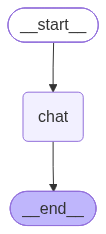

In [3]:
graph

In [4]:
while True:
    user_input = input("You: ")
    if user_input.lower() in ["exit", "quit"]:
        break
    result = graph.invoke({"messages": [{"role": "user", "content": user_input}]}, config)
    print("Bot:", result["messages"][-1].content)

Bot: Hello! How can I help you today?
Bot: Nice to meet you, Sachin Mishra! How can I assist you today?
Bot: Absolutely, I’d love to help you get started with LangGraph! 🚀

---

## 1. Quick Overview

| Concept | What it is | Why it matters |
|---------|------------|----------------|
| **Graph** | Directed graph of *nodes* (functions, prompts, LLM calls) and *edges* (transitions). | Gives you a visual, modular way to design complex workflows. |
| **Node** | A single step (e.g., a prompt, a function call, a retrieval). | Keeps logic isolated and reusable. |
| **Edge** | The rule that decides *where* to go next based on the node’s output. | Enables conditional branching, loops, and parallelism. |
| **State** | A dictionary that carries data (inputs, outputs, context) through the graph. | Keeps everything in one place; you can read/write from anywhere. |
| **LLM Call** | A node that sends a prompt to a language model and returns the response. | Core of most LangGraph workflows. |
| **Memor

In [5]:
result

{'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='2311d6b0-c5fb-4037-ba42-6b2db693aaf7'),
  AIMessage(content='Hello! How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 72, 'total_tokens': 109, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 19, 'rejected_prediction_tokens': None, 'text_tokens': None}, 'compute_units': None, 'prompt_tokens_details': None, 'queue_time': 0.329625639, 'prompt_time': 0.003377439, 'completion_time': 0.040081764, 'total_time': 0.043459203}, 'model_provider': 'openai', 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_851252edc2', 'id': 'chatcmpl-8a8fce4b-9d1c-483d-b0ba-2806360f2563', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0ddfd-7b64-7fd1-8b6d-cac87b5b54f1-0', tool_calls=[], invalid_tool_calls=[], usage_metadata=

## Deletion

In [6]:
# delete_memory_chat.py

import os
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from langchain_openai import ChatOpenAI
from langchain_core.messages import RemoveMessage

load_dotenv(override=True)

def get_groq_llm():
    return ChatOpenAI(
        model="openai/gpt-oss-20b",
        base_url="https://api.groq.com/openai/v1",
        api_key=os.getenv("GROQ_API_KEY"),
        temperature=0.7, max_tokens=2000
    )

model = get_groq_llm()

def chat(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

def cleanup(state: MessagesState):
    messages = state["messages"]

    if len(messages) > 6:
        to_remove = messages[:4]  # delete oldest messages
        print([m.id for m in to_remove])  # print ids of messages to be removed
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}

    return {}



In [7]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat)
builder.add_node("cleanup", cleanup)

builder.add_edge(START, "chat")
builder.add_edge("chat", "cleanup")
builder.add_edge("cleanup", "__end__")

graph = builder.compile(checkpointer=InMemorySaver())

config = {"configurable": {"thread_id": "delete-demo"}}



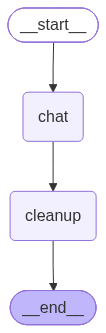

In [8]:
graph

In [9]:
while True:
    user_input = input("You: ")
    if user_input.lower() in ["exit", "quit"]:
        break
    result = graph.invoke({"messages": [{"role": "user", "content": user_input}]}, config)
    print("Bot:", result["messages"][-1].content)

Bot: Hello! How can I help you today?
Bot: Nice to meet you, Sachin Mishra! How can I assist you today?
Bot: That’s awesome! LangGraph is a powerful framework for building graph‑oriented language models (LLMs) and conversational agents. Let’s make sure you’re on the right track.

---

## 1. Quick Overview

| Feature | What it does | Why it matters |
|---------|--------------|----------------|
| **Node‑Based Workflow** | Define reusable “nodes” (functions, prompts, embeddings, etc.) | Keeps logic modular & testable |
| **Dynamic Routing** | Decide next node based on LLM output or external data | Enables branching conversations |
| **State Management** | Central `state` object that flows through nodes | Keeps context consistent |
| **Integration** | Plug in any LLM provider (OpenAI, Anthropic, local) | Flexibility for experimentation |
| **Tracing & Debugging** | Automatic logs & visualizations | Easier to spot bottlenecks & errors |

---

## 2. Getting Started

### 2.1 Install

```bash


In [10]:
result

{'messages': [HumanMessage(content='Okay, now I want to go deeper into the HITL concept. Please give me the answer for that. ', additional_kwargs={}, response_metadata={}, id='21e434f6-c455-483f-b803-94d0be638492'),
  AIMessage(content='### Human‑in‑the‑Loop (HITL) in LangGraph  \nHuman‑in‑the‑Loop (HITL) is a design pattern where a human operator (or a set of operators) is inserted into the AI workflow to **monitor, intervene, or approve** certain steps.  \nIn LangGraph, HITL is not a built‑in component per se, but the graph abstraction makes it straightforward to weave humans into any part of the conversation or workflow.\n\nBelow is a deep dive into:\n\n| Topic | What it covers |\n|-------|----------------|\n| 1. Why HITL matters | Safety, compliance, quality, and trust |\n| 2. HITL entry points in a graph | Decision nodes, verification nodes, fallback nodes |\n| 3. Implementation patterns | Prompt‑based, UI‑based, API‑based |\n| 4. State & context handling | What to expose to the h

In [ ]:
# ---- Run ----
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm Sachin"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "I am learning LangGraph"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Explain short term memory"}]}, config)
result = graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]}, config)

print(result["messages"][-1].content)


## Summarization

In [1]:
# summary_memory_chat.py

import os
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, RemoveMessage

load_dotenv(override=True)

def get_groq_llm():
    return ChatOpenAI(
        model="openai/gpt-oss-20b",
        base_url="https://api.groq.com/openai/v1",
        api_key=os.getenv("GROQ_API_KEY"),
        temperature=0.7, max_tokens=2000
    )

model = get_groq_llm()

class ChatState(MessagesState):
    summary: str

def chat(state: ChatState):
    messages = []

    if state["summary"]:
        messages.append({
            "role": "system",
            "content": f"Conversation summary:\n{state['summary']}"
        })

    messages.extend(state["messages"])
    messages.append(HumanMessage(content="Please respond to the user input. If the username is present in the entire conversation, then refer to the username if the user is going to ask explicitly about his or her name."))
    response = model.invoke(messages)
    return {"messages": [response]}

def summarize(state: ChatState):
    prompt = "Summarize the conversation so far. in a way that you can include important details in future interactions. like nameof the user, or the person you  are talking & other important deatils."

    summary_input = state["messages"] + [HumanMessage(content=prompt)]
    response = model.invoke(summary_input)

    to_delete = state["messages"][:4] 

    print([m.id for m in to_delete])  # print ids of messages to be removed

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in to_delete],
    }

def should_summarize(state: ChatState):
    return len(state["messages"]) > 6



In [2]:
builder = StateGraph(ChatState)
builder.add_node("chat", chat)
builder.add_node("summarize", summarize)

builder.add_edge(START, "chat")
builder.add_conditional_edges(
    "chat",
    should_summarize,
    {True: "summarize", False: "__end__"}
)
builder.add_edge("summarize", "__end__")

graph = builder.compile(checkpointer=InMemorySaver())

config = {"configurable": {"thread_id": "summary-demo"}}


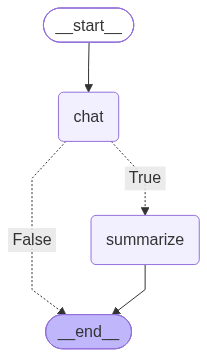

In [3]:
graph


In [ ]:
# while True:
#     user_input = input("You: ")
#     if user_input.lower() in ["exit", "quit"]:
#         break
#     result = graph.invoke({"messages": [{"role": "user", "content": user_input}],"summary":""}, config)
#     print("Bot:", result["messages"][-1].content)

Bot: Hello! How can I help you today?
Bot: Nice to meet you, Sachin Mishra! How can I help you today?
Bot: That’s great, Sachin! LangGraph is a powerful framework for building graph‑structured LLM agents. What aspects are you exploring—graph construction, node types, or integration with your own LLM? Let me know how I can help!
['6547bb87-2f50-4255-80f3-33adefcb08f6', 'lc_run--01a0de16-cab0-7373-bebe-8a348891cba8-0', '2e39bc59-29fe-47af-a96c-efd5668c8aac', 'lc_run--01a0de16-e772-78f0-b845-acee7054b6f6-0']
Bot: **Human‑in‑the‑Loop (HITL) in LangGraph**

LangGraph lets you build agent workflows as directed graphs where each node performs a specific task (e.g., calling an LLM, querying a database, or executing a function).  
A *Human‑in‑the‑Loop* node is simply a node that pauses the automated flow and hands control over to a human. The human can:

1. **Validate or correct** the agent’s output before it’s used downstream.  
2. **Provide missing information** that the LLM or other nodes ca

In [4]:
result

NameError: name 'result' is not defined

In [5]:


# ---- Run ----
graph.invoke({"messages": [HumanMessage(content="Hi")], "summary": ""}, config)
graph.invoke({"messages": [HumanMessage(content="Hi my name is Sachin")], "summary": ""}, config)
graph.invoke({"messages": [HumanMessage(content="Explain short term memory")], "summary": ""}, config)
result = graph.invoke({"messages": [HumanMessage(content="What is my name?")], "summary": ""}, config)

print(result["messages"][-1].content)

['92d05b1b-eb3f-478a-8b91-02955aadc01b', 'lc_run--01a0de1b-cba8-7d21-a1ab-395bbcfcb85c-0', 'b38f0b23-c12a-4b4c-8a5b-2407803e3de5', 'lc_run--01a0de1b-cdc8-7573-921c-e63619473a2f-0']
Your name is Sachin.


In [6]:
result

{'messages': [HumanMessage(content='Explain short term memory', additional_kwargs={}, response_metadata={}, id='21326edb-9018-42aa-b546-cb7efd2c7d30'),
  AIMessage(content='Short‑term memory (STM), also called **working memory**, is the part of our memory system that holds a limited amount of information for a brief period—usually seconds to a minute—so we can manipulate, process, or use it in real‑time tasks.\n\n### Key features of short‑term memory\n\n| Feature | What it means |\n|---------|---------------|\n| **Capacity** | Roughly 7\u202f±\u202f2 “chunks” of information (Miller’s law). A chunk could be a single digit, a word, or a larger meaningful unit. |\n| **Duration** | Without rehearsal, information decays after about 15–30\u202fseconds. |\n| **Rehearsal** | Repeating or mentally recoding information (e.g., silently saying a phone number) keeps it alive longer. |\n| **Active processing** | STM isn’t just passive storage; it’s where we do calculations, plan, reason, and integra